# SQD Workflow: Stage 1 (circuit construction) + Stage 2 (sampling) + Stage 2B (sbd export)

- **Stage 1** (`stage1.py`): Hamiltonian (FCIDUMP, from PySCF or supplied) -> CCSD -> LUCJ ansatz -> transpiled circuit -> `.qpy` + JSON metadata.
- **Stage 2** (`stage2.py`): loads the `.qpy`, samples with Qiskit Aer, writes bitstrings + counts and a JSON diagnostics summary.
- **Stage 2B** (`stage2b.py`): splits Stage 2's sampled bitstrings into the alpha/beta determinant files the downstream C++ app `sbd` (r-ccs-cms/sbd) actually consumes, plus an HF-only calibration file and a ready-to-paste run command.
- A single `CONFIG` dict (below) drives all three stages; `run_stage1(CONFIG)` / `run_stage2(CONFIG)` / `run_stage2b(CONFIG)` are importable for standalone scripts.
- Out of scope: sampling-quality metrics (Gini, compactness), orbital-ordering permutations, optimisation loops, and the diagonalisation itself (`sbd` does that).

In [1]:
from pathlib import Path

import stage1
import stage2
import stage2b

print("stage1, stage2, and stage2b modules loaded.")

stage1, stage2, and stage2b modules loaded.


## CONFIG

Single dict driving all three stages. `fcidump_source` selects Stage 1's
entry point: `"pyscf"` builds an FCIDUMP from the molecular parameters below;
`"existing"` loads `existing_fcidump_path` directly (set `atom`/`basis` to
`None` in that case - they are only used for metadata bookkeeping).

`preset` selects a named system from `stage1.PRESETS` (`n2_equilibrium`,
`n2_stretched`, `n2_very_stretched`, `h2_sto3g`) which fills in
`atom`/`basis`/active-space fields - but only where the value here is still
`None`; set any of those fields explicitly to override the preset. This cell
runs `n2_equilibrium` as the primary demonstration; the cross-preset
comparison and the H2 calibration test further down use their own copies.

The `sbd_*` / `*_determinants` / `write_bdetfile` keys configure Stage 2B's
export to the downstream C++ app's `--adetfile`/`--bdetfile` format - see
`stage2b.py`'s module docstring for what that app expects.

In [27]:
CONFIG = {
    # --- Stage 1: Hamiltonian source ---
    "fcidump_source": "pyscf",  # "pyscf" or "existing"
    "existing_fcidump_path": None,  # used only when fcidump_source == "existing"

    # --- Stage 1: system preset (see stage1.PRESETS) ---
    "preset": None,

    # --- Stage 1: molecular parameters (Path A). None => filled in from `preset`. ---
    "atom": [["N", (0.0, 0.0, 0.0)], ["N", (0.0, 0.0, 1.55)]] ,
    "basis": "6-31g",
    "charge": 0,
    "spin": 0,
    "n_frozen_core": 4,
    "n_active_orbitals": 10,
    "n_active_electrons": 6,

    # --- Stage 1: CCSD / CASCI failsafe + exact-wavefunction baseline ---
    "run_casci_reference": True,
    "casci_reference_max_norb": 12,

    # --- Stage 1: circuit construction ---
    "optimization_level": 3,
    # Builds a second, unmasked (interaction_pairs=None) LUCJ ansatz alongside
    # the masked one, to quantify what the locality mask costs. See
    # stage1.build_unmasked_lucj_operator / print_ansatz_comparison.
    "build_unmasked_comparison": True,

    # --- Stage 1: output locations ---
    "output_dir": "outputs",
    "fcidump_filename": "n2_cas610_155.fcidump",
    "circuit_filename": "n2_cas610_155_lucj.qpy",

    # --- Stage 2: sampling ---
    # SQD literature commonly uses 1e5-1e7 shots; 10,000 is too few to expose
    # rare correlated configurations, so the default here is 1,000,000.
    "shots": 1_000_000,
    "seed": 42,

    # --- Stage 2: output locations ---
    "bitstring_filename": "n2_cas610_155_bitstrings.txt",

    # --- Stage 2: bitstring file format (this is a separate artefact from the
    # Stage 2B sbd export below; it may keep its header/counts for analysis) ---
    "bit_order_mode": "qiskit",  # Stage 2B requires this to stay 'qiskit'
    "output_separator": " ",
    "include_header": True,
    "include_counts": True,
    # When True, write one bitstring file per bit-order mode (mode in the
    # filename) so all four can be tried against other consumers at once.
    "emit_all_bit_order_variants": False,

    # --- Stage 2: diagnostics ---
    "top_k_report": 10,

    # --- Stage 2B: sbd export (see stage2b.py) ---
    # 'split' is CONFIRMED correct (verified against the sbd repo's
    # AlphaDets.txt example file - see stage2b module docstring). The
    # alternatives remain available as a fallback only.
    "sbd_bit_transform": "split",  # 'split' | 'split_reverse' | 'split_swap'
    # When True, write adet/bdet files for all three transforms at once.
    "emit_all_sbd_variants": False,
    # sbd defaults beta=alpha when --bdetfile is omitted; set False to skip
    # writing the beta file and rely on that default.
    "write_bdetfile": True,
    # Keep only the N most frequently sampled alpha/beta determinants (each
    # side independently). None = keep all. Matters because sbd's Hilbert
    # space is the *product* of the alpha and beta sets, so it grows as N^2.
    "max_determinants": None,
}

print("CONFIG:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG:
  fcidump_source: pyscf
  existing_fcidump_path: None
  preset: None
  atom: [['N', (0.0, 0.0, 0.0)], ['N', (0.0, 0.0, 1.55)]]
  basis: 6-31g
  charge: 0
  spin: 0
  n_frozen_core: 4
  n_active_orbitals: 10
  n_active_electrons: 6
  run_casci_reference: True
  casci_reference_max_norb: 12
  optimization_level: 3
  build_unmasked_comparison: True
  output_dir: outputs
  fcidump_filename: n2_cas610_155.fcidump
  circuit_filename: n2_cas610_155_lucj.qpy
  shots: 1000000
  seed: 42
  bitstring_filename: n2_cas610_155_bitstrings.txt
  bit_order_mode: qiskit
  output_separator:  
  include_header: True
  include_counts: True
  emit_all_bit_order_variants: False
  top_k_report: 10
  sbd_bit_transform: split
  emit_all_sbd_variants: False
  write_bdetfile: True
  max_determinants: None


## Stage 1: circuit construction

Builds/loads the FCIDUMP, analyses the exact (CASCI) wavefunction's
concentration as a physical baseline, runs CCSD in the active space (with a
loud failsafe warning if CCSD diverges relative to CASCI), builds the masked
LUCJ operator (`n_reps=None`, `optimize=False` - mandatory) plus an unmasked
comparison ansatz, transpiles both, prints a masked-vs-unmasked comparison
table, and serialises both to `.qpy` + JSON metadata (the masked circuit's
metadata records the unmasked `.qpy` path so Stage 2 can find it). Every step
prints its own diagnostics.

In [28]:
stage1_result = stage1.run_stage1(CONFIG)

print()
print("Stage 1 outputs:")
print(f"  FCIDUMP         : {stage1_result.fcidump_path}")
print(f"  QPY (masked)    : {stage1_result.qpy_path}")
print(f"  Metadata (masked): {stage1_result.metadata_path}")
if stage1_result.unmasked_stats is not None:
    print(f"  QPY (unmasked)  : {stage1_result.unmasked_stats.qpy_path}")
    print(f"  Metadata (unmasked): {stage1_result.unmasked_stats.metadata_path}")

No preset selected (CONFIG['preset'] is falsy); using explicit CONFIG values.
=== Stage 1 / Path A: generating FCIDUMP from PySCF ===
  HF energy               = -108.5873225618
  Active space orbitals   = 10
  Active space electrons  = (3, 3) (alpha, beta)
  Frozen core orbitals    = 4
  FCIDUMP written to      = outputs/n2_cas610_155.fcidump
Reloading active-space Hamiltonian from outputs/n2_cas610_155.fcidump ...
Parsing outputs/n2_cas610_155.fcidump
Parsing outputs/n2_cas610_155.fcidump
  norb (active) = 10
  nelec (active) = (3, 3)
  core energy = -98.7678301361
  active-space RHF energy = -108.5873225618
Analysing exact (CASCI) wavefunction concentration ...
  CI space dimension            = 14400
  Weight on top determinant     = 0.759644
  Determinants for 90% weight   = 11
  Determinants for 99% weight   = 94
  Determinants for 99.9% weight = 334
Running CCSD in the active space ...
  CCSD converged      = True
  CCSD total energy   = -108.8280746455
  CCSD correlation E  = -0

## Stage 2: sampling

Loads the masked `.qpy` circuit produced above, samples it with
`AerSimulator` (prints wall-clock sampling time), prints all diagnostics
(unique bitstring count, top-10, particle-number checks). If Stage 1 built an
unmasked comparison circuit, its path is read from the masked circuit's
metadata and it is sampled too, with a side-by-side sampling-diversity
comparison (unique bitstring count, top-1 fraction) printed at the end.
Writes the bitstring file(s) + JSON summary for each circuit sampled.

`CONFIG["qpy_path"]` is set from Stage 1's result so this cell can also be
re-run standalone against any previously produced `.qpy` file.

In [29]:
CONFIG["qpy_path"] = str(stage1_result.qpy_path)

stage2_result = stage2.run_stage2(CONFIG)

Loading metadata from outputs/n2_cas610_155_lucj.json ...
  norb = 10, nelec = [3, 3]
--- Sampling MASKED circuit ---
Loading circuit from outputs/n2_cas610_155_lucj.qpy ...
  qubits = 20, depth = 1354
Sampling with AerSimulator: shots=1000000, seed=42 ...
  Got 163 unique bitstrings from 1000000 shots in 3.29s.
Total shots: 1000000
Unique bitstrings: 163
Top 10 bitstrings:
  00000001110000000111  count=980804  prob=0.980804
  00000101010000010101  count=1689  prob=0.001689
  00000010110000001011  count=1530  prob=0.001530
  00000010110000000111  count=1487  prob=0.001487
  00000001110000001011  count=1460  prob=0.001460
  00000001110100000011  count=1394  prob=0.001394
  01000000110000000111  count=1350  prob=0.001350
  00000001110010000101  count=978  prob=0.000978
  00100001010000000111  count=954  prob=0.000954
  00000100110000010011  count=951  prob=0.000951
Fraction of shots on the single most frequent bitstring: 0.980804
Particle-number check (fraction of shots, by weight):
  to

## Stage 2B: sbd export

Splits Stage 2's sampled bitstrings into the alpha/beta determinant files
the downstream C++ app (`sbd`, `apps/chemistry_tpb_selected_basis_diagonalization`)
actually consumes via `--adetfile`/`--bdetfile`: one bitstring per line, no
header, no counts. Prints the product-space diagnostics (sbd forms the
tensor product of the alpha and beta sectors - confirmed in the sbd README),
applies `CONFIG["max_determinants"]` truncation if set, and guarantees the
Hartree-Fock determinant is present in both files (sbd uses it as the
Davidson initial state after sorting).

Also writes an HF-only calibration file and prints a ready-to-paste `mpirun`
command for the files this run produced.

In [31]:
sbd_export = stage2b.run_stage2b(CONFIG)
hf_calibration = stage2b.write_hf_only_determinant(CONFIG)
stage2b.print_sbd_command(CONFIG, sbd_export)

=== Stage 2B: sbd export ===
Loaded 163 unique full bitstrings from outputs/n2_cas610_155_bitstrings.txt
Loading metadata from outputs/n2_cas610_155_lucj.json ...
  norb = 10, nelec = [3, 3]
--- sbd export: sbd_bit_transform='split' ---
  alpha determinants kept: 44/44 (100.0000% of sampled weight)
  beta determinants kept:  48/48 (100.0000% of sampled weight)
Determinant file written to outputs/n2_cas610_155_adets.txt (44 determinants)
Determinant file written to outputs/n2_cas610_155_bdets.txt (48 determinants)
Product-space diagnostics (tensor product of alpha x beta sectors):
  unique full bitstrings sampled  : 163
  unique alpha determinants       : 44
  unique beta determinants        : 48
  implied product-space dimension : 2112 (= 44 x 48)
  product_dim / unique_full_bitstrings ratio: 12.96x
  full CI space dimension (C(norb,na)*C(norb,nb)): 14400
  product space as % of full CI space: 14.6667%
sbd export diagnostics written to outputs/n2_cas610_155_sbd_export.json
=== Stage 2B

## H2 calibration test: the smallest possible end-to-end run

`h2_sto3g` (H2 at 0.74 A, sto-3g, no frozen core, norb=2, nelec=(1,1)) is the
smallest system this pipeline can build - useful for a fast, cheap sanity
check of the whole chain, and specifically for calibrating the sbd bit
ordering: `write_hf_only_determinant` below writes a single-determinant file
that, fed to sbd, must reproduce the printed Hartree-Fock energy exactly. If
it doesn't, try `CONFIG["sbd_bit_transform"] = "split_reverse"` or
`"split_swap"` (though `"split"` is already confirmed correct against the
sbd repository's own example file - see `stage2b.py`).

This runs Stage 1 -> Stage 2 -> Stage 2B end to end on its own `CONFIG` copy
so it doesn't disturb the primary `n2_equilibrium` outputs above.

In [6]:
h2_config = dict(CONFIG)  # fresh copy, same CONFIG pattern
h2_config["preset"] = "h2_sto3g"
h2_config["atom"] = None
h2_config["basis"] = None
h2_config["n_frozen_core"] = None
h2_config["n_active_orbitals"] = None
h2_config["n_active_electrons"] = None
h2_config["fcidump_filename"] = "h2_sto3g.fcidump"
h2_config["circuit_filename"] = "h2_sto3g_lucj.qpy"
h2_config["bitstring_filename"] = "h2_sto3g_bitstrings.txt"

h2_stage1 = stage1.run_stage1(h2_config)
h2_config["qpy_path"] = str(h2_stage1.qpy_path)
h2_stage2 = stage2.run_stage2(h2_config)
h2_sbd_export = stage2b.run_stage2b(h2_config)
h2_hf_calibration = stage2b.write_hf_only_determinant(h2_config)
stage2b.print_sbd_command(h2_config, h2_sbd_export)

Active preset: 'h2_sto3g'
=== Stage 1 / Path A: generating FCIDUMP from PySCF ===
  HF energy               = -1.1167593074
  Active space orbitals   = 2
  Active space electrons  = (1, 1) (alpha, beta)
  Frozen core orbitals    = 0
  FCIDUMP written to      = outputs/h2_sto3g.fcidump
Reloading active-space Hamiltonian from outputs/h2_sto3g.fcidump ...
Parsing outputs/h2_sto3g.fcidump
Parsing outputs/h2_sto3g.fcidump
  norb (active) = 2
  nelec (active) = (1, 1)
  core energy = 0.7151043391
  active-space RHF energy = -1.1167593074
Analysing exact (CASCI) wavefunction concentration ...
  CI space dimension            = 4
  Weight on top determinant     = 0.987334
  Determinants for 90% weight   = 1
  Determinants for 99% weight   = 2
  Determinants for 99.9% weight = 2
Running CCSD in the active space ...
  CCSD converged      = True
  CCSD total energy   = -1.1372839986
  CCSD correlation E  = -0.0205246912
Computing CASCI (exact diagonalisation) reference in the active space ...
  CA

  Got 4 unique bitstrings from 1000000 shots in 0.19s.
Total shots: 1000000
Unique bitstrings: 4
Top 4 bitstrings:
  0101  count=998459  prob=0.998459
  1010  count=766  prob=0.000766
  0110  count=390  prob=0.000390
  1001  count=385  prob=0.000385
Fraction of shots on the single most frequent bitstring: 0.998459
Particle-number check (fraction of shots, by weight):
  total set bits == 2: 100.0000%
  alpha set bits == 1: 100.0000%
  beta set bits == 1: 100.0000%
Bitstring file written to outputs/h2_sto3g_bitstrings.txt (4 unique bitstrings)
JSON summary written to outputs/h2_sto3g_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/h2_sto3g_lucj_unmasked.qpy ...
  qubits = 4, depth = 17
Sampling with AerSimulator: shots=1000000, seed=42 ...
  Got 2 unique bitstrings from 1000000 shots in 0.19s.
Total shots: 1000000
Unique bitstrings: 2
Top 2 bitstrings:
  0101  count=987482  prob=0.987482
  1010  count=12518  prob=0.012518
Fraction of shots on the single mos

## Cross-preset comparison: quantifying HF-dominance vs. the locality mask

The single-preset run above showed the sampler heavily concentrated on one
bitstring. Two candidate explanations were proposed:

  (a) N2 in this active space is genuinely HF-dominated at this geometry
  (b) the locality mask discards most Jastrow elements, collapsing the
      ansatz back toward HF

This section runs Stage 1 + Stage 2 for all three presets
(`n2_equilibrium`, `n2_stretched`, `n2_very_stretched`), stretching the N-N
bond to reduce HF character (a), while the masked-vs-unmasked ansatz
comparison built into each Stage 1 run isolates the mask's own cost (b).
Each preset gets its own output filenames so nothing is overwritten.

Note: `n2_very_stretched` is expected to trip the CCSD-vs-CASCI divergence
failsafe (single-reference CCSD breaks down for stretched N2) - the loud
warning is expected there, and its ansatz/sampling numbers should be read as
"unreliable input" rather than a mask-quality measurement.

In [7]:
preset_results: dict[str, dict] = {}

for preset_name in ["n2_equilibrium", "n2_stretched", "n2_very_stretched"]:
    print()
    print("#" * 78)
    print(f"# Preset: {preset_name}")
    print("#" * 78)

    preset_config = dict(CONFIG)  # fresh copy per preset; same CONFIG pattern
    preset_config["preset"] = preset_name
    preset_config["atom"] = None
    preset_config["basis"] = None
    preset_config["n_frozen_core"] = None
    preset_config["n_active_orbitals"] = None
    preset_config["n_active_electrons"] = None
    preset_config["fcidump_filename"] = f"{preset_name}.fcidump"
    preset_config["circuit_filename"] = f"{preset_name}_lucj.qpy"
    preset_config["bitstring_filename"] = f"{preset_name}_bitstrings.txt"

    s1 = stage1.run_stage1(preset_config)
    preset_config["qpy_path"] = str(s1.qpy_path)
    s2 = stage2.run_stage2(preset_config)
    s2b = stage2b.run_stage2b(preset_config)

    preset_results[preset_name] = {"stage1": s1, "stage2": s2, "stage2b": s2b}

print()
print("Cross-preset comparison complete.")


##############################################################################
# Preset: n2_equilibrium
##############################################################################
Active preset: 'n2_equilibrium'
=== Stage 1 / Path A: generating FCIDUMP from PySCF ===


  HF energy               = -108.8677463470
  Active space orbitals   = 6
  Active space electrons  = (3, 3) (alpha, beta)
  Frozen core orbitals    = 4
  FCIDUMP written to      = outputs/n2_equilibrium.fcidump
Reloading active-space Hamiltonian from outputs/n2_equilibrium.fcidump ...
Parsing outputs/n2_equilibrium.fcidump
Parsing outputs/n2_equilibrium.fcidump
  norb (active) = 6
  nelec (active) = (3, 3)
  core energy = -97.5489212436
  active-space RHF energy = -108.8677463470
Analysing exact (CASCI) wavefunction concentration ...
  CI space dimension            = 400
  Weight on top determinant     = 0.939267
  Determinants for 90% weight   = 1
  Determinants for 99% weight   = 7
  Determinants for 99.9% weight = 25
Running CCSD in the active space ...
  CCSD converged      = True
  CCSD total energy   = -108.9459113976
  CCSD correlation E  = -0.0781650506
Computing CASCI (exact diagonalisation) reference in the active space ...
  CASCI (exact) energy = -108.9467159424
Locality m

Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=371, two-qubit gates=1196
Masked ansatz variational energy: -108.8994796168
Building UNMASKED LUCJ operator (interaction_pairs=None; comparison only) ...
  Actual n_reps chosen by full-rank factorisation: 18
Building Qiskit circuit (HF prep + UCJ + measure_all) ...
  Circuit built: 12 qubits, depth 3
Pre-transpilation:  depth=3, two-qubit gates=0
Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=516, two-qubit gates=1720
Unmasked ansatz variational energy: -108.9454183881

=== Masked vs unmasked LUCJ ansatz comparison ===
                                        masked          unmasked
n_reps                                      18                18
circuit depth                              371               516
two-qubit gate count                      1196              1720
variational energy             -108.89947961

  Got 48 unique bitstrings from 1000000 shots in 0.32s.
Total shots: 1000000
Unique bitstrings: 48
Top 10 bitstrings:
  000111000111  count=994115  prob=0.994115
  011001000111  count=816  prob=0.000816
  000111011001  count=805  prob=0.000805
  010011010011  count=643  prob=0.000643
  001101001101  count=576  prob=0.000576
  010101000111  count=276  prob=0.000276
  000111010101  count=271  prob=0.000271
  001011000111  count=255  prob=0.000255
  000111001011  count=252  prob=0.000252
  001011010101  count=146  prob=0.000146
Fraction of shots on the single most frequent bitstring: 0.994115
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_equilibrium_bitstrings.txt (48 unique bitstrings)
JSON summary written to outputs/n2_equilibrium_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/n2_equilibrium_lucj_unmasked.qpy ...
 

  Got 61 unique bitstrings from 1000000 shots in 0.34s.
Total shots: 1000000
Unique bitstrings: 61
Top 10 bitstrings:
  000111000111  count=940770  prob=0.940770
  010011010011  count=15426  prob=0.015426
  001101001101  count=15367  prob=0.015367
  010011001101  count=6999  prob=0.006999
  001101010011  count=6770  prob=0.006770
  000111011001  count=3374  prob=0.003374
  011001000111  count=3319  prob=0.003319
  001110001110  count=1260  prob=0.001260
  010110010110  count=1228  prob=0.001228
  011001011001  count=762  prob=0.000762
Fraction of shots on the single most frequent bitstring: 0.940770
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_equilibrium_bitstrings_unmasked.txt (61 unique bitstrings)
JSON summary written to outputs/n2_equilibrium_bitstrings_unmasked.json

=== Masked vs unmasked sampling diversity ===
                          

...

  Got 72 unique bitstrings from 1000000 shots in 0.32s.
Total shots: 1000000
Unique bitstrings: 72
Top 10 bitstrings:
  000111000111  count=980009  prob=0.980009
  010101010101  count=4600  prob=0.004600
  001011001011  count=4318  prob=0.004318
  001011000111  count=3037  prob=0.003037
  000111001011  count=2963  prob=0.002963
  000111110100  count=454  prob=0.000454
  110100000111  count=436  prob=0.000436
  000111001101  count=342  prob=0.000342
  001101000111  count=334  prob=0.000334
  010011000111  count=258  prob=0.000258
Fraction of shots on the single most frequent bitstring: 0.980009
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_stretched_bitstrings.txt (72 unique bitstrings)
JSON summary written to outputs/n2_stretched_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/n2_stretched_lucj_unmasked.qpy ...
  q

  Got 93 unique bitstrings from 1000000 shots in 0.38s.
Total shots: 1000000
Unique bitstrings: 93
Top 10 bitstrings:
  000111000111  count=796389  prob=0.796389
  010101010101  count=52793  prob=0.052793
  001011001011  count=52424  prob=0.052424
  001011010101  count=14487  prob=0.014487
  010101001011  count=14186  prob=0.014186
  011001011001  count=8095  prob=0.008095
  001101010011  count=6761  prob=0.006761
  010011001101  count=6749  prob=0.006749
  100110100110  count=5595  prob=0.005595
  001011100110  count=3925  prob=0.003925
Fraction of shots on the single most frequent bitstring: 0.796389
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_stretched_bitstrings_unmasked.txt (93 unique bitstrings)
JSON summary written to outputs/n2_stretched_bitstrings_unmasked.json

=== Masked vs unmasked sampling diversity ===
                           

Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=367, two-qubit gates=1176
Masked ansatz variational energy: -108.3329115631
Building UNMASKED LUCJ operator (interaction_pairs=None; comparison only) ...
  Actual n_reps chosen by full-rank factorisation: 18
Building Qiskit circuit (HF prep + UCJ + measure_all) ...
  Circuit built: 12 qubits, depth 3
Pre-transpilation:  depth=3, two-qubit gates=0
Transpilation path: preset pass manager with ffsim.qiskit.PRE_INIT pre-init stage.
Post-transpilation: depth=511, two-qubit gates=1700
Unmasked ansatz variational energy: -108.4459133125

=== Masked vs unmasked LUCJ ansatz comparison ===
                                        masked          unmasked
n_reps                                      18                18
circuit depth                              367               511
two-qubit gate count                      1176              1700
variational energy             -108.33291156

  Got 197 unique bitstrings from 1000000 shots in 0.35s.
Total shots: 1000000
Unique bitstrings: 197
Top 10 bitstrings:
  000111000111  count=874596  prob=0.874596
  001101001101  count=16795  prob=0.016795
  010011010011  count=15766  prob=0.015766
  000111110010  count=11951  prob=0.011951
  110010000111  count=11860  prob=0.011860
  000111010011  count=11623  prob=0.011623
  010011000111  count=11476  prob=0.011476
  010110000111  count=3305  prob=0.003305
  001101000111  count=3270  prob=0.003270
  000111001101  count=3191  prob=0.003191
Fraction of shots on the single most frequent bitstring: 0.874596
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_very_stretched_bitstrings.txt (197 unique bitstrings)
JSON summary written to outputs/n2_very_stretched_bitstrings.json
--- Sampling UNMASKED circuit ---
Loading circuit from outputs/n2_very_stretc

  Got 100 unique bitstrings from 1000000 shots in 0.59s.
Total shots: 1000000
Unique bitstrings: 100
Top 10 bitstrings:
  000111000111  count=328835  prob=0.328835
  010011010011  count=81282  prob=0.081282
  011001011001  count=80944  prob=0.080944
  001101001101  count=78949  prob=0.078949
  100110100110  count=61534  prob=0.061534
  010011001101  count=31152  prob=0.031152
  001101010011  count=30769  prob=0.030769
  010011100110  count=17404  prob=0.017404
  100110010011  count=17246  prob=0.017246
  001101100110  count=17025  prob=0.017025
Fraction of shots on the single most frequent bitstring: 0.328835
Particle-number check (fraction of shots, by weight):
  total set bits == 6: 100.0000%
  alpha set bits == 3: 100.0000%
  beta set bits == 3: 100.0000%
Bitstring file written to outputs/n2_very_stretched_bitstrings_unmasked.txt (100 unique bitstrings)
JSON summary written to outputs/n2_very_stretched_bitstrings_unmasked.json

=== Masked vs unmasked sampling diversity ===
         

In [8]:
print(f"{'preset':20s}{'HF':>13s}{'CCSD':>13s}{'CASCI':>13s}{'exact top wt':>13s}")
for name, r in preset_results.items():
    s1 = r["stage1"]
    m = s1.metadata
    exact_top = s1.exact_wavefunction.weight_on_top_determinant if s1.exact_wavefunction else float("nan")
    print(f"{name:20s}{m['hf_energy']:>13.6f}{m['ccsd_energy']:>13.6f}{m['casci_reference_energy']:>13.6f}{exact_top:>13.4f}")

print()
print(f"{'preset':20s}{'masked E err(mHa)':>19s}{'unmasked E err(mHa)':>21s}")
for name, r in preset_results.items():
    s1 = r["stage1"]
    ccsd_e = s1.metadata["ccsd_energy"]
    masked_err = 1000 * (s1.masked_stats.variational_energy - ccsd_e)
    unmasked_err = 1000 * (s1.unmasked_stats.variational_energy - ccsd_e) if s1.unmasked_stats else float("nan")
    print(f"{name:20s}{masked_err:>19.4f}{unmasked_err:>21.4f}")

print()
print(f"{'preset':20s}{'masked uniq':>13s}{'unmasked uniq':>15s}{'masked top1':>13s}{'unmasked top1':>15s}")
for name, r in preset_results.items():
    s2 = r["stage2"]
    masked = s2["masked"]
    unmasked = s2["unmasked"]
    u_uniq = unmasked["unique_bitstrings"] if unmasked else float("nan")
    u_top1 = unmasked["top1_fraction"] if unmasked else float("nan")
    print(f"{name:20s}{masked['unique_bitstrings']:>13d}{u_uniq:>15}{masked['top1_fraction']:>13.4f}{u_top1:>15.4f}")

print()
print(f"{'preset':20s}{'n_adets':>10s}{'n_bdets':>10s}{'product dim':>13s}{'% of full CI':>14s}")
for name, r in preset_results.items():
    diag = r["stage2b"]["variants"][r["stage2b"]["default_transform"]]["diagnostics"]
    print(
        f"{name:20s}{diag['n_alpha_determinants']:>10d}{diag['n_beta_determinants']:>10d}"
        f"{diag['product_space_dimension']:>13d}{diag['product_space_pct_of_full_ci']:>14.4f}"
    )

preset                         HF         CCSD        CASCI exact top wt
n2_equilibrium        -108.867746  -108.945911  -108.946716       0.9393
n2_stretched          -108.587323  -108.801058  -108.811675       0.7705
n2_very_stretched     -108.309601  -108.764548  -108.726795       0.3455

preset                masked E err(mHa)  unmasked E err(mHa)
n2_equilibrium                  46.4318               0.4930
n2_stretched                   150.1446              11.0087
n2_very_stretched              431.6361             318.6344

preset                masked uniq  unmasked uniq  masked top1  unmasked top1
n2_equilibrium                 48             61       0.9941         0.9408
n2_stretched                   72             93       0.9800         0.7964
n2_very_stretched             197            100       0.8746         0.3288

preset                 n_adets   n_bdets  product dim  % of full CI
n2_equilibrium              15        16          240       60.0000
n2_stretched     

## Outputs and next steps

Per run (primary demo uses `n2_cas66*`; the H2 calibration uses
`h2_sto3g*`; the cross-preset section uses `<preset_name>*`), `outputs/`
contains:

- `*.fcidump` - the active-space Hamiltonian.
- `*_lucj.qpy` / `.json` - the **masked** Stage 1 circuit + metadata.
- `*_lucj_unmasked.qpy` / `.json` - the unmasked comparison circuit + metadata (comparison-only).
- `*_bitstrings.txt` / `.json` (+ `*_bitstrings_unmasked.*`) - Stage 2's own
  bitstring + counts artefact, for this notebook's analysis only. **Not**
  what sbd reads.
- `*_adets.txt` / `*_bdets.txt` (+ `*_sbd_export.json`) - **Stage 2B's sbd
  export**: one determinant per line, no header, no counts, sorted ascending
  (HF first). This is what `--adetfile`/`--bdetfile` actually take.
- `*_hf_only_adets.txt` / `*_hf_only_bdets.txt` - the single-determinant
  calibration file (see the H2 section above).

**sbd (Stage 3, external, not implemented here) takes exactly two/three
files: the `.fcidump`, the `*_adets.txt`, and (unless relying on sbd's
beta=alpha default) the `*_bdets.txt`.** Everything else - the Stage 2
bitstrings file, unmasked-ansatz artefacts, and JSON summaries - is
diagnostic output for this notebook, not sbd input.

**Bit ordering for the sbd export is CONFIRMED** (`CONFIG["sbd_bit_transform"]
= "split"`): verified against the sbd repository's own `AlphaDets.txt`
example file - see `stage2b.py`'s module docstring. The alternative
transforms remain available as a fallback only. The Stage 2 bitstring file's
own `CONFIG["bit_order_mode"]` is a separate, still-unconfirmed setting for
that other artefact.

Sampling-quality metrics (Gini, compactness), orbital-ordering permutations,
optimisation loops, and the diagonalisation itself (sbd does that) remain
out of scope for this notebook.

In [4]:
from pathlib import Path

out = Path("outputs")
for name in ["n2_cas66_adets.txt", "n2_cas66_bdets.txt"]:
    lines = (out / name).read_text().strip().split("\n")
    print(f"\n{name}: {len(lines)} determinants")
    print(f"  width: {set(len(l) for l in lines)}          (expect {{6}})")
    print(f"  electrons: {set(l.count('1') for l in lines)}  (expect {{3}})")
    print(f"  comments: {sum(1 for l in lines if l.startswith('#'))}  (expect 0)")
    print(f"  first 3: {lines[:3]}")
    print(f"  HF '000111' present: {'000111' in lines}")


n2_cas66_adets.txt: 16 determinants
  width: {6}          (expect {6})
  electrons: {3}  (expect {3})
  comments: 0  (expect 0)
  first 3: ['000111', '001011', '001101']
  HF '000111' present: True

n2_cas66_bdets.txt: 15 determinants
  width: {6}          (expect {6})
  electrons: {3}  (expect {3})
  comments: 0  (expect 0)
  first 3: ['000111', '001011', '001101']
  HF '000111' present: True


In [8]:
import copy

cfg_un = copy.deepcopy(CONFIG)
cfg_un["bitstring_filename"] = "n2_cas66_bitstrings_unmasked.txt"

stage2b.run_stage2b(cfg_un)

=== Stage 2B: sbd export ===
Loaded 71 unique full bitstrings from outputs/n2_cas66_bitstrings_unmasked.txt
Loading metadata from outputs/n2_cas66_lucj.json ...
  norb = 6, nelec = [3, 3]
--- sbd export: sbd_bit_transform='split' ---
  alpha determinants kept: 20/20 (100.0000% of sampled weight)
  beta determinants kept:  19/19 (100.0000% of sampled weight)
Determinant file written to outputs/n2_cas66_bitstrings_unmasked_adets.txt (20 determinants)
Determinant file written to outputs/n2_cas66_bitstrings_unmasked_bdets.txt (19 determinants)
Product-space diagnostics (tensor product of alpha x beta sectors):
  unique full bitstrings sampled  : 71
  unique alpha determinants       : 20
  unique beta determinants        : 19
  implied product-space dimension : 380 (= 20 x 19)
  product_dim / unique_full_bitstrings ratio: 5.35x
  full CI space dimension (C(norb,na)*C(norb,nb)): 400
  product space as % of full CI space: 95.0000%
sbd export diagnostics written to outputs/n2_cas66_bitstrings_

{'norb': 6,
 'nelec': [3, 3],
 'source_bitstring_file': 'outputs/n2_cas66_bitstrings_unmasked.txt',
 'default_transform': 'split',
 'max_determinants': None,
 'write_bdetfile': True,
 'variants': {'split': {'mode': 'split',
   'adet_path': 'outputs/n2_cas66_bitstrings_unmasked_adets.txt',
   'bdet_path': 'outputs/n2_cas66_bitstrings_unmasked_bdets.txt',
   'alpha_selection': {'n_available': 20,
    'n_kept': 20,
    'kept_weight_fraction': 1.0},
   'beta_selection': {'n_available': 19,
    'n_kept': 19,
    'kept_weight_fraction': 1.0},
   'diagnostics': {'n_unique_full_bitstrings': 71,
    'n_alpha_determinants': 20,
    'n_beta_determinants': 19,
    'product_space_dimension': 380,
    'product_dim_over_unique_full_ratio': 5.352112676056338,
    'full_ci_space_dimension': 400,
    'product_space_pct_of_full_ci': 95.0}}}}

In [15]:
import copy, subprocess, re
from pathlib import Path
import pandas as pd

SBD = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"
OUT = Path.home() / "sqd-project/outputs"

E_HF, E_CASCI = -108.8677463470, -108.9467159424

def run_sbd(adet, bdet, fcidump=OUT / "n2_cas66.fcidump"):
    """Run sbd and parse the ground-state energy."""
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD),
         "--fcidump", str(fcidump),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "20",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError(r.stdout[-2000:] + r.stderr[-2000:])
    return float(m.group(1))

rows = []
for label, bitfile in [("masked",   "n2_cas66_bitstrings.txt"),
                       ("unmasked", "n2_cas66_bitstrings_unmasked.txt")]:
    for budget in [3, 5, 8, 10, 15, None]:
        cfg = copy.deepcopy(CONFIG)
        cfg["bitstring_filename"] = bitfile
        cfg["max_determinants"]   = budget
        res = stage2b.run_stage2b(cfg)

        # adjust these two lines to match what run_stage2b actually returns
        adet, bdet = Path(res.adet_path), Path(res.bdet_path)

        n_a = len(adet.read_text().strip().split("\n"))
        n_b = len(bdet.read_text().strip().split("\n"))
        E   = run_sbd(adet, bdet)

        rows.append({
            "ansatz": label,
            "budget": budget if budget else "all",
            "n_alpha": n_a, "n_beta": n_b,
            "dim": n_a * n_b,
            "pct_CI": 100 * n_a * n_b / 400,
            "E": E,
            "err_mHa": (E - E_CASCI) * 1000,
            "pct_corr": 100 * (E - E_HF) / (E_CASCI - E_HF),
        })

df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

=== Stage 2B: sbd export ===
Loaded 50 unique full bitstrings from outputs/n2_cas66_bitstrings.txt
Loading metadata from outputs/n2_cas66_lucj.json ...
  norb = 6, nelec = [3, 3]
--- sbd export: sbd_bit_transform='split' ---
  alpha determinants kept: 3/15 (99.8204% of sampled weight)
  beta determinants kept:  3/14 (99.8198% of sampled weight)
Determinant file written to outputs/n2_cas66_adets.txt (3 determinants)
Determinant file written to outputs/n2_cas66_bdets.txt (3 determinants)
Product-space diagnostics (tensor product of alpha x beta sectors):
  unique full bitstrings sampled  : 50
  unique alpha determinants       : 3
  unique beta determinants        : 3
  implied product-space dimension : 9 (= 3 x 3)
  product_dim / unique_full_bitstrings ratio: 0.18x
  full CI space dimension (C(norb,na)*C(norb,nb)): 400
  product space as % of full CI space: 2.2500%
sbd export diagnostics written to outputs/n2_cas66_sbd_export.json
=== Stage 2B complete ===


AttributeError: 'dict' object has no attribute 'adet_path'

In [10]:
import copy
cfg = copy.deepcopy(CONFIG)
cfg["bitstring_filename"] = "n2_cas66_bitstrings.txt"
cfg["max_determinants"] = 5
res = stage2b.run_stage2b(cfg)
print(type(res))
print(res.keys() if isinstance(res, dict) else dir(res))
print(res)

=== Stage 2B: sbd export ===
Loaded 50 unique full bitstrings from outputs/n2_cas66_bitstrings.txt
Loading metadata from outputs/n2_cas66_lucj.json ...
  norb = 6, nelec = [3, 3]
--- sbd export: sbd_bit_transform='split' ---
  alpha determinants kept: 5/15 (99.9368% of sampled weight)
  beta determinants kept:  5/14 (99.9388% of sampled weight)
Determinant file written to outputs/n2_cas66_adets.txt (5 determinants)
Determinant file written to outputs/n2_cas66_bdets.txt (5 determinants)
Product-space diagnostics (tensor product of alpha x beta sectors):
  unique full bitstrings sampled  : 50
  unique alpha determinants       : 5
  unique beta determinants        : 5
  implied product-space dimension : 25 (= 5 x 5)
  product_dim / unique_full_bitstrings ratio: 0.50x
  full CI space dimension (C(norb,na)*C(norb,nb)): 400
  product space as % of full CI space: 6.2500%
sbd export diagnostics written to outputs/n2_cas66_sbd_export.json
=== Stage 2B complete ===
<class 'dict'>
dict_keys(['nor

In [11]:
adet = OUT / "n2_cas66_adets.txt"
bdet = OUT / "n2_cas66_bdets.txt"

In [16]:
import copy, subprocess, re, shutil
from pathlib import Path
import pandas as pd

SBD = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"
OUT = Path.home() / "sqd-project/outputs"
SWEEP = OUT / "sweep"; SWEEP.mkdir(exist_ok=True)

E_HF, E_CASCI = -108.8677463470, -108.9467159424
FCIDUMP = OUT / "n2_cas66.fcidump"

def run_sbd(adet, bdet):
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD),
         "--fcidump", str(FCIDUMP),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "20",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError((r.stdout + r.stderr)[-2000:])
    return float(m.group(1))

rows = []
for label, bitfile in [("masked",   "n2_cas66_bitstrings.txt"),
                       ("unmasked", "n2_cas66_bitstrings_unmasked.txt")]:
    for budget in [3, 5, 8, 10, 15, None]:
        cfg = copy.deepcopy(CONFIG)
        cfg["bitstring_filename"] = bitfile
        cfg["max_determinants"]   = budget
        stage2b.run_stage2b(cfg)

        tag = f"{label}_b{budget or 'all'}"
        adet = SWEEP / f"{tag}_adets.txt"
        bdet = SWEEP / f"{tag}_bdets.txt"
        shutil.copy(OUT / "n2_cas66_adets.txt", adet)
        shutil.copy(OUT / "n2_cas66_bdets.txt", bdet)

        n_a = len(adet.read_text().strip().split("\n"))
        n_b = len(bdet.read_text().strip().split("\n"))
        E   = run_sbd(adet, bdet)

        rows.append({
            "ansatz": label, "budget": budget or "all",
            "n_alpha": n_a, "n_beta": n_b, "dim": n_a * n_b,
            "pct_CI": 100 * n_a * n_b / 400,
            "E": E,
            "err_mHa": (E - E_CASCI) * 1000,
            "pct_corr": 100 * (E - E_HF) / (E_CASCI - E_HF),
        })
        print(f"{tag:18s} dim={n_a*n_b:4d}  E={E:.8f}  err={rows[-1]['err_mHa']:8.3f} mHa")

df = pd.DataFrame(rows)
print()
print(df.round(4).to_string(index=False))
df.to_csv(OUT / "budget_sweep_n2_cas66.csv", index=False)

=== Stage 2B: sbd export ===
Loaded 50 unique full bitstrings from outputs/n2_cas66_bitstrings.txt
Loading metadata from outputs/n2_cas66_lucj.json ...
  norb = 6, nelec = [3, 3]
--- sbd export: sbd_bit_transform='split' ---
  alpha determinants kept: 3/15 (99.8204% of sampled weight)
  beta determinants kept:  3/14 (99.8198% of sampled weight)
Determinant file written to outputs/n2_cas66_adets.txt (3 determinants)
Determinant file written to outputs/n2_cas66_bdets.txt (3 determinants)
Product-space diagnostics (tensor product of alpha x beta sectors):
  unique full bitstrings sampled  : 50
  unique alpha determinants       : 3
  unique beta determinants        : 3
  implied product-space dimension : 9 (= 3 x 3)
  product_dim / unique_full_bitstrings ratio: 0.18x
  full CI space dimension (C(norb,na)*C(norb,nb)): 400
  product space as % of full CI space: 2.2500%
sbd export diagnostics written to outputs/n2_cas66_sbd_export.json
=== Stage 2B complete ===
masked_b3          dim=   9  E=

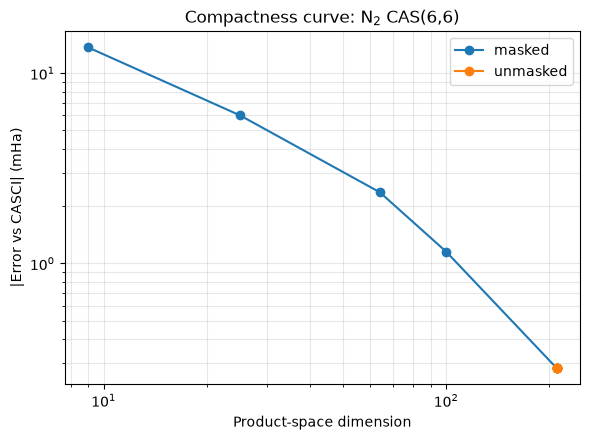

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4.5))
for label, g in df.groupby("ansatz"):
    ax.loglog(g["dim"], g["err_mHa"].abs(), "o-", label=label)
ax.set_xlabel("Product-space dimension")
ax.set_ylabel("|Error vs CASCI| (mHa)")
ax.set_title("Compactness curve: N$_2$ CAS(6,6)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

In [18]:
print(df.groupby("ansatz").size())
print()
print(df.to_string(index=False))

ansatz
masked      6
unmasked    6
dtype: int64

  ansatz budget  n_alpha  n_beta  dim  pct_CI           E   err_mHa  pct_corr
  masked      3        3       3    9    2.25 -108.933046 13.670372 82.689070
  masked      5        5       5   25    6.25 -108.940714  6.001979 92.399633
  masked      8        8       8   64   16.00 -108.944350  2.366088 97.003799
  masked     10       10      10  100   25.00 -108.945564  1.152134 98.541041
  masked     15       15      14  210   52.50 -108.946434  0.281932 99.642987
  masked    all       15      14  210   52.50 -108.946434  0.281932 99.642987
unmasked      3       15      14  210   52.50 -108.946434  0.281932 99.642987
unmasked      5       15      14  210   52.50 -108.946434  0.281932 99.642987
unmasked      8       15      14  210   52.50 -108.946434  0.281932 99.642987
unmasked     10       15      14  210   52.50 -108.946434  0.281932 99.642987
unmasked     15       15      14  210   52.50 -108.946434  0.281932 99.642987
unmasked    all

In [19]:
import inspect
print(inspect.getsource(stage2b.run_stage2b))

def run_stage2b(config: dict[str, Any]) -> dict[str, Any]:
    """Run the Stage 2B sbd export: Stage 2 bitstrings -> sbd adet/bdet files.

    Reads the Stage 2 bitstring text file at
    <output_dir>/<bitstring_filename>, which must have been written with
    bit_order_mode='qiskit' (the CONFIG default) and include_counts=True,
    since the alpha/beta split (sbd_transform) is defined on that raw
    representation. Writes one adet/bdet file pair per
    CONFIG['sbd_bit_transform'] variant requested (all four if
    CONFIG['emit_all_sbd_variants'] is True), plus a JSON diagnostics summary.
    """
    print("=== Stage 2B: sbd export ===")

    if config.get("bit_order_mode", "qiskit") != "qiskit":
        raise ValueError(
            "run_stage2b requires the Stage 2 bitstring file to have been "
            "written with bit_order_mode='qiskit' (the CONFIG default), "
            "since the alpha/beta split is defined on that raw "
            "representation. Set CONFIG['bit_order_

In [33]:
import copy, subprocess, re, shutil
from collections import Counter
from pathlib import Path
import pandas as pd

SBD   = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"
OUT   = Path.home() / "sqd-project/outputs"
SWEEP = OUT / "sweep"; SWEEP.mkdir(exist_ok=True)

NORB, NELEC = 10, 3
E_HF, E_CASCI = -108.5873225618, -108.8443004284
FCIDUMP = OUT / "n2_cas610_155.fcidump"

def load_counts(path):
    """Read '<bitstring> <count>' lines, skipping comments."""
    counts = {}
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        bits, n = line.split()
        counts[bits] = int(n)
    return counts

def marginals(counts):
    """Split full bitstrings into alpha/beta halves, weighted by count."""
    a, b = Counter(), Counter()
    for bits, n in counts.items():
        a[bits[-NORB:]] += n      # rightmost norb chars = alpha
        b[bits[:NORB]]  += n      # leftmost  norb chars = beta
    return a, b

def write_dets(counter, budget, path):
    """Top-`budget` determinants by frequency, one per line, no header."""
    items = counter.most_common(budget) if budget else counter.most_common()
    dets  = sorted(d for d, _ in items)
    hf = "0" * (NORB - NELEC) + "1" * NELEC
    if hf not in dets:
        dets = sorted(dets + [hf])
        print(f"  (HF determinant {hf} was missing; prepended)")
    Path(path).write_text("\n".join(dets) + "\n")
    return len(dets)

def run_sbd(adet, bdet):
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD), "--fcidump", str(FCIDUMP),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "20",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError((r.stdout + r.stderr)[-2000:])
    return float(m.group(1))

# ---- sweep ----
sources = {
    "masked":   OUT / "n2_cas610_155_bitstrings.txt",
    "unmasked": OUT / "n2_cas610_155_bitstrings_unmasked.txt",
}

rows = []
for label, src in sources.items():
    counts = load_counts(src)
    a_counts, b_counts = marginals(counts)
    print(f"\n{label}: {len(counts)} full bitstrings -> "
          f"{len(a_counts)} alpha, {len(b_counts)} beta")

    for budget in [1, 2, 3, 5, 8, 10, 15, None]:
        tag  = f"{label}_b{budget or 'all'}"
        adet = SWEEP / f"{tag}_adets.txt"
        bdet = SWEEP / f"{tag}_bdets.txt"
        n_a = write_dets(a_counts, budget, adet)
        n_b = write_dets(b_counts, budget, bdet)
        E   = run_sbd(adet, bdet)
        rows.append({
            "ansatz": label, "budget": budget or "all",
            "n_alpha": n_a, "n_beta": n_b, "dim": n_a * n_b,
            "pct_CI": 100 * n_a * n_b / 400,
            "E": E,
            "err_mHa": (E - E_CASCI) * 1000,
            "pct_corr": 100 * (E - E_HF) / (E_CASCI - E_HF),
        })
        print(f"  {tag:16s} dim={n_a*n_b:4d}  E={E:.8f}  "
              f"err={rows[-1]['err_mHa']:8.3f} mHa")

df = pd.DataFrame(rows)
print()
print(df.round(4).to_string(index=False))
df.to_csv(OUT / "budget_sweep_n2_cas66.csv", index=False)


masked: 163 full bitstrings -> 44 alpha, 48 beta
  masked_b1        dim=   1  E=-108.58732256  err= 256.978 mHa
  masked_b2        dim=   4  E=-108.59661814  err= 247.682 mHa
  masked_b3        dim=   9  E=-108.60525250  err= 239.048 mHa
  masked_b5        dim=  25  E=-108.74006064  err= 104.240 mHa
  masked_b8        dim=  64  E=-108.74293867  err= 101.362 mHa
  masked_b10       dim= 100  E=-108.77079197  err=  73.508 mHa
  masked_b15       dim= 225  E=-108.79770804  err=  46.592 mHa
  masked_ball      dim=2112  E=-108.84007078  err=   4.230 mHa

unmasked: 551 full bitstrings -> 86 alpha, 84 beta
  unmasked_b1      dim=   1  E=-108.58732256  err= 256.978 mHa
  unmasked_b2      dim=   4  E=-108.64947371  err= 194.827 mHa
  unmasked_b3      dim=   9  E=-108.70830969  err= 135.991 mHa
  unmasked_b5      dim=  25  E=-108.74006064  err= 104.240 mHa
  unmasked_b8      dim=  64  E=-108.79608951  err=  48.211 mHa
  unmasked_b10     dim= 100  E=-108.80930103  err=  34.999 mHa
  unmasked_b15  

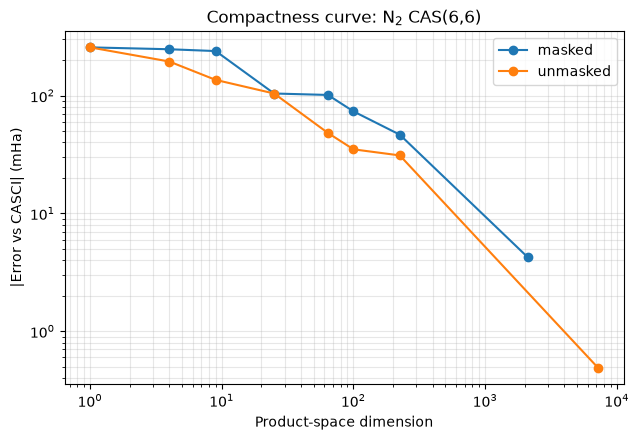

In [34]:
import matplotlib.pyplot as plt

assert df.groupby("ansatz").size().min() > 1, "One series has a single point"

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for label, g in df.groupby("ansatz"):
    g = g.sort_values("dim")
    ax.loglog(g["dim"], g["err_mHa"].abs(), "o-", label=label)
ax.set_xlabel("Product-space dimension")
ax.set_ylabel("|Error vs CASCI| (mHa)")
ax.set_title("Compactness curve: N$_2$ CAS(6,6)")
ax.legend(); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

In [35]:
p = df.pivot_table(index="dim", columns="ansatz", values="err_mHa")
p["diff_mHa"] = (p["masked"] - p["unmasked"]).abs()
print(p.round(4).to_string())

ansatz    masked  unmasked  diff_mHa
dim                                 
1       256.9779  256.9779    0.0000
4       247.6823  194.8267   52.8556
9       239.0479  135.9907  103.0572
25      104.2398  104.2398    0.0000
64      101.3618   48.2109   53.1508
100      73.5085   34.9994   38.5091
225      46.5924   31.0662   15.5262
2112      4.2296       NaN       NaN
7224         NaN    0.4862       NaN


In [32]:
NORB, NELEC = 10, 3          # was 6, 3
FCIDUMP = OUT / "n2_cas610_155.fcidump"
E_HF, E_CASCI = <from Stage 1>, <from Stage 1>

sources = {
    "masked":   OUT / "n2_cas610_155_bitstrings.txt",
    "unmasked": OUT / "n2_cas610_155_bitstrings_unmasked.txt",
}

SyntaxError: invalid syntax (4220310164.py, line 3)

In [38]:
# ============================================================================
# ORBITAL ORDERING EXPERIMENT
# N2 CAS(6,10) @ 1.55 A
#
# Question: does variational energy rank orbital orderings the same way
# SQD subspace energy does?
#
# Design: N random permutations of the active orbitals, applied to the LUCJ
# OPERATOR (not the MO coefficients). Mask applied AFTER permutation. Fixed
# product-space budget across all orderings. Everything else identical.
# ============================================================================

import copy, re, shutil, subprocess, time
from collections import Counter
from math import comb
from pathlib import Path

import numpy as np
import pandas as pd
import pyscf, pyscf.cc, pyscf.mcscf
import ffsim
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import AerSimulator

# ---------------------------------------------------------------- settings
BOND        = 1.55
BASIS       = "6-31g"
N_FROZEN    = 4
NORB        = 10
NELEC       = (3, 3)
N_PERMS     = 25          # number of random orderings (plus identity)
SHOTS       = 1_000_000
BUDGET      = 15          # determinants kept per spin sector -> dim 225
SEED        = 2026

OUT   = Path.home() / "sqd-project" / "outputs"
WORK  = OUT / "ordering"; WORK.mkdir(parents=True, exist_ok=True)
SBD   = Path.home() / "sqd-project/sbd/apps/chemistry_tpb_selected_basis_diagonalization/diag"

CI_DIM = comb(NORB, NELEC[0]) * comb(NORB, NELEC[1])
rng = np.random.default_rng(SEED)

alpha_alpha = [(p, p + 1) for p in range(NORB - 1)]
alpha_beta  = [(p, p) for p in range(0, NORB, 4)]

print(f"N2 CAS({sum(NELEC)},{NORB}) @ {BOND} A | CI dim = {CI_DIM}")
print(f"{N_PERMS} random orderings + identity | budget {BUDGET}/spin "
      f"-> dim {BUDGET**2} ({100*BUDGET**2/CI_DIM:.2f}% of CI)\n")

# ---------------------------------------------------------------- reference
mol = pyscf.gto.Mole()
mol.build(atom=[["N", (0, 0, 0)], ["N", (0, 0, BOND)]],
          basis=BASIS, symmetry=False, verbose=0)
mf = pyscf.scf.RHF(mol).run(verbose=0)

mol_data = ffsim.MolecularData.from_scf(mf, active_space=range(N_FROZEN, N_FROZEN + NORB))
cc = pyscf.cc.CCSD(mf, frozen=[i for i in range(mol.nao_nr())
                               if i not in range(N_FROZEN, N_FROZEN + NORB)]).run(verbose=0)

cas = pyscf.mcscf.CASCI(mf, ncas=NORB, nelecas=NELEC)
cas.ncore = N_FROZEN
cas.run(verbose=0)

E_HF, E_CASCI = mol_data.hf_energy, cas.e_tot
ham = ffsim.linear_operator(mol_data.hamiltonian, norb=NORB, nelec=NELEC)
ref = ffsim.hartree_fock_state(NORB, NELEC)

print(f"HF    = {E_HF:.8f}")
print(f"CCSD  = {cc.e_tot:.8f}")
print(f"CASCI = {E_CASCI:.8f}\n")

FCIDUMP = WORK / "n2_cas610_155.fcidump"
mol_data.to_fcidump(str(FCIDUMP))

# ---------------------------------------------------------------- helpers
op_full = ffsim.UCJOpSpinBalanced.from_t_amplitudes(t2=cc.t2, t1=cc.t1, n_reps=None)

def permute_operator(op, perm):
    """Relabel orbital indices, absorbing the permutation into the rotations.
    The UNMASKED operator is physically unchanged by this."""
    P = np.eye(op.norb)[list(perm)]
    J = np.asarray(op.diag_coulomb_mats)      # (n_reps, 2, norb, norb)
    U = np.asarray(op.orbital_rotations)
    kw = dict(diag_coulomb_mats=np.einsum('ij,rsjk,lk->rsil', P, J, P),
              orbital_rotations=np.einsum('rij,kj->rik', U, P))
    if op.final_orbital_rotation is not None:
        kw['final_orbital_rotation'] = op.final_orbital_rotation
    return ffsim.UCJOpSpinBalanced(**kw)

_m_aa = np.zeros((NORB, NORB), bool)
for p, q in alpha_alpha: _m_aa[p, q] = _m_aa[q, p] = True
np.fill_diagonal(_m_aa, True)
_m_ab = np.zeros((NORB, NORB), bool)
for p, q in alpha_beta: _m_ab[p, q] = _m_ab[q, p] = True

def apply_mask(op):
    J = np.asarray(op.diag_coulomb_mats).copy()
    J[:, 0] *= _m_aa
    J[:, 1] *= _m_ab
    kw = dict(diag_coulomb_mats=J,
              orbital_rotations=np.asarray(op.orbital_rotations))
    if op.final_orbital_rotation is not None:
        kw['final_orbital_rotation'] = op.final_orbital_rotation
    return ffsim.UCJOpSpinBalanced(**kw)

def variational_energy(op):
    """<psi|H|psi>. Splits real/imaginary parts because PySCF's contraction
    requires float64, while apply_unitary returns complex128. Valid because
    H is real symmetric, so the cross terms cancel."""
    s = ffsim.apply_unitary(ref, op, norb=NORB, nelec=NELEC)
    if np.iscomplexobj(s):
        sr = np.ascontiguousarray(s.real, dtype=np.float64)
        si = np.ascontiguousarray(s.imag, dtype=np.float64)
        return float(np.dot(sr, ham @ sr) + np.dot(si, ham @ si))
    s = np.ascontiguousarray(s, dtype=np.float64)
    return float(np.dot(s, ham @ s))

def retained_J_fraction(op):
    J = np.asarray(op.diag_coulomb_mats)
    tot  = np.sum(J[:, 0]**2) + np.sum(J[:, 1]**2)
    kept = np.sum((J[:, 0]*_m_aa)**2) + np.sum((J[:, 1]*_m_ab)**2)
    return float(kept / tot)

sim = AerSimulator(seed_simulator=SEED)

def sample(op):
    q  = QuantumRegister(2*NORB, "q")
    qc = QuantumCircuit(q)
    qc.append(ffsim.qiskit.PrepareHartreeFockJW(NORB, NELEC), q)
    qc.append(ffsim.qiskit.UCJOpSpinBalancedJW(op), q)
    qc.measure_all()
    tqc = transpile(qc, sim, optimization_level=3)
    return sim.run(tqc, shots=SHOTS).result().get_counts(), tqc

HF_DET = "0"*(NORB - NELEC[0]) + "1"*NELEC[0]

def marginals(counts):
    a, b = Counter(), Counter()
    for bits, n in counts.items():
        bits = bits.replace(" ", "")
        a[bits[-NORB:]] += n
        b[bits[:NORB]]  += n
    return a, b

def write_dets(counter, budget, path):
    dets = sorted(d for d, _ in counter.most_common(budget))
    if HF_DET not in dets:
        dets = sorted(dets + [HF_DET])
    Path(path).write_text("\n".join(dets) + "\n")
    return len(dets)

def run_sbd(adet, bdet):
    r = subprocess.run(
        ["mpirun", "-np", "1", str(SBD), "--fcidump", str(FCIDUMP),
         "--adetfile", str(adet), "--bdetfile", str(bdet),
         "--method", "0", "--iteration", "30",
         "--block", "100", "--tolerance", "1e-8"],
        capture_output=True, text=True, cwd=SBD.parent)
    m = re.search(r"Sample-based diagonalization: Energy = ([-\d.]+)", r.stdout)
    if not m:
        raise RuntimeError((r.stdout + r.stderr)[-1500:])
    return float(m.group(1))

# --------------------------------------------------- correctness gate
e_id = variational_energy(op_full)
devs = [abs(variational_energy(permute_operator(op_full, rng.permutation(NORB))) - e_id)
        for _ in range(5)]
print(f"Permutation invariance of UNMASKED operator: max dev = {max(devs):.2e}")
assert max(devs) < 1e-8, "Permutation is not a symmetry -- check index convention"
print("GATE PASSED\n")

# --------------------------------------------------- main loop
orderings = {"identity": np.arange(NORB)}
seen = {tuple(range(NORB))}
while len(orderings) <= N_PERMS:
    p = rng.permutation(NORB)
    if tuple(p) not in seen:
        seen.add(tuple(p))
        orderings[f"p{len(orderings):02d}"] = p

rows, t0 = [], time.time()
for i, (name, perm) in enumerate(orderings.items(), 1):
    op_masked = apply_mask(permute_operator(op_full, perm))

    counts, tqc = sample(op_masked)
    a_c, b_c = marginals(counts)

    adet = WORK / f"{name}_adets.txt"
    bdet = WORK / f"{name}_bdets.txt"
    n_a = write_dets(a_c, BUDGET, adet)
    n_b = write_dets(b_c, BUDGET, bdet)

    E_sub = run_sbd(adet, bdet)
    E_var = variational_energy(op_masked)
    top1  = max(counts.values()) / SHOTS

    rows.append({
        "ordering": name,
        "perm": "".join(map(str, perm)),
        "E_var": E_var,
        "err_var_mHa": (E_var - E_CASCI) * 1000,
        "retained_J": retained_J_fraction(permute_operator(op_full, perm)),
        "n_unique": len(counts),
        "n_alpha_tot": len(a_c),
        "n_beta_tot": len(b_c),
        "top1": top1,
        "dim": n_a * n_b,
        "E_sub": E_sub,
        "err_sub_mHa": (E_sub - E_CASCI) * 1000,
        "pct_corr": 100 * (E_sub - E_HF) / (E_CASCI - E_HF),
        "depth": tqc.depth(),
        "cx": sum(v for k, v in tqc.count_ops().items() if k in ("cz", "cx", "ecr")),
    })
    print(f"[{i:2d}/{len(orderings)}] {name:9s} "
          f"var_err={rows[-1]['err_var_mHa']:8.2f}  "
          f"sub_err={rows[-1]['err_sub_mHa']:7.2f} mHa  "
          f"uniq={len(counts):4d}  J={rows[-1]['retained_J']:.3f}")

df = pd.DataFrame(rows)
print(f"\nElapsed {time.time()-t0:.0f} s")
df.to_csv(OUT / "ordering_experiment_n2_cas610_155.csv", index=False)

# --------------------------------------------------- the question
print("\n" + "="*64)
print("Q: does variational energy predict SQD subspace accuracy?")
print("="*64)
r_p = df["err_var_mHa"].corr(df["err_sub_mHa"])
r_s = df["err_var_mHa"].corr(df["err_sub_mHa"], method="spearman")
print(f"  Pearson  r = {r_p:+.3f}")
print(f"  Spearman r = {r_s:+.3f}   (rank correlation -- the relevant one)")

print("\nOther predictors vs subspace error (Spearman):")
for col in ["retained_J", "top1", "n_unique", "n_alpha_tot"]:
    print(f"  {col:12s} {df[col].corr(df['err_sub_mHa'], method='spearman'):+.3f}")

best_var = df.loc[df["err_var_mHa"].idxmin()]
best_sub = df.loc[df["err_sub_mHa"].idxmin()]
print(f"\nBest by variational energy : {best_var['ordering']} "
      f"(sub_err {best_var['err_sub_mHa']:.2f} mHa)")
print(f"Best by subspace energy    : {best_sub['ordering']} "
      f"(sub_err {best_sub['err_sub_mHa']:.2f} mHa)")
print(f"Cost of selecting by variational energy: "
      f"{best_var['err_sub_mHa'] - best_sub['err_sub_mHa']:.2f} mHa")

print(f"\nSpread in subspace error: {df.err_sub_mHa.min():.2f} to "
      f"{df.err_sub_mHa.max():.2f} mHa  (sd {df.err_sub_mHa.std():.2f})")

print("\n" + df[["ordering","perm","err_var_mHa","err_sub_mHa",
                 "retained_J","n_unique","top1"]].round(3).to_string(index=False))

N2 CAS(6,10) @ 1.55 A | CI dim = 14400
25 random orderings + identity | budget 15/spin -> dim 225 (1.56% of CI)

HF    = -108.58732256
CCSD  = -108.82807464
CASCI = -108.84430043

Permutation invariance of UNMASKED operator: max dev = 5.33e-12
GATE PASSED

[ 1/26] identity  var_err=  193.29  sub_err=  39.11 mHa  uniq= 167  J=0.287
[ 2/26] p01       var_err=  210.99  sub_err=  25.78 mHa  uniq= 123  J=0.214
[ 3/26] p02       var_err=  253.15  sub_err=  77.67 mHa  uniq=  77  J=0.231
[ 4/26] p03       var_err=  221.47  sub_err=  50.61 mHa  uniq= 154  J=0.210
[ 5/26] p04       var_err=  250.91  sub_err=  20.79 mHa  uniq=  95  J=0.233
[ 6/26] p05       var_err=  215.51  sub_err=  30.77 mHa  uniq= 120  J=0.204
[ 7/26] p06       var_err=  203.97  sub_err=  36.35 mHa  uniq= 118  J=0.226
[ 8/26] p07       var_err=  230.80  sub_err=  22.04 mHa  uniq= 135  J=0.304
[ 9/26] p08       var_err=  198.58  sub_err=  48.70 mHa  uniq= 155  J=0.232
[10/26] p09       var_err=  227.44  sub_err=  50.40 mHa  un

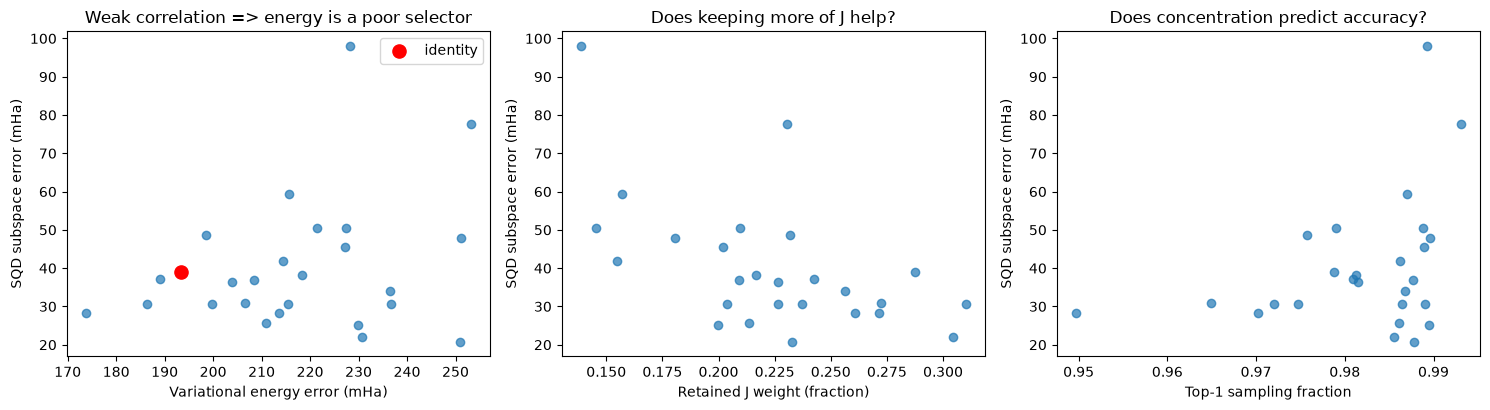

In [39]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
idx = df["ordering"] == "identity"

ax[0].scatter(df.err_var_mHa, df.err_sub_mHa, alpha=0.7)
ax[0].scatter(df.loc[idx,"err_var_mHa"], df.loc[idx,"err_sub_mHa"],
              color="red", s=90, zorder=5, label="identity")
ax[0].set_xlabel("Variational energy error (mHa)")
ax[0].set_ylabel("SQD subspace error (mHa)")
ax[0].set_title("Weak correlation => energy is a poor selector")
ax[0].legend()

ax[1].scatter(df.retained_J, df.err_sub_mHa, alpha=0.7)
ax[1].set_xlabel("Retained J weight (fraction)")
ax[1].set_ylabel("SQD subspace error (mHa)")
ax[1].set_title("Does keeping more of J help?")

ax[2].scatter(df.top1, df.err_sub_mHa, alpha=0.7)
ax[2].set_xlabel("Top-1 sampling fraction")
ax[2].set_ylabel("SQD subspace error (mHa)")
ax[2].set_title("Does concentration predict accuracy?")

plt.tight_layout(); plt.show()

In [40]:
print(df[["ordering","n_unique","n_alpha_tot","n_beta_tot","dim","err_sub_mHa"]]
      .sort_values("err_sub_mHa").to_string(index=False))
print("\nAll dims equal?", df["dim"].nunique() == 1, "| dims:", sorted(df["dim"].unique()))

ordering  n_unique  n_alpha_tot  n_beta_tot  dim  err_sub_mHa
     p04        95           35          35  225    20.788177
     p07       135           39          37  225    22.041515
     p13       121           37          41  225    25.181146
     p01       123           35          36  225    25.783923
     p16       163           42          41  225    28.337868
     p18       247           52          46  225    28.374872
     p19       155           37          40  225    30.673452
     p17       130           38          37  225    30.765959
     p22       157           41          45  225    30.765959
     p05       120           41          41  225    30.765959
     p20       189           40          45  225    30.817192
     p15       111           31          36  225    33.929396
     p06       118           31          32  225    36.350632
     p12       123           35          37  225    36.874636
     p24       150           41          41  225    37.190992
     p21